# Salary Prediction using `Salary_Data.csv`

This notebook replicates the steps in `ml.ipynb` but uses the provided `Salary_Data.csv` dataset: load data, EDA, visualize, train a linear regression model, predict, evaluate, and plot the regression line.

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


Shape: (30, 2)
Columns: ['YearsExperience', 'Salary']


,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


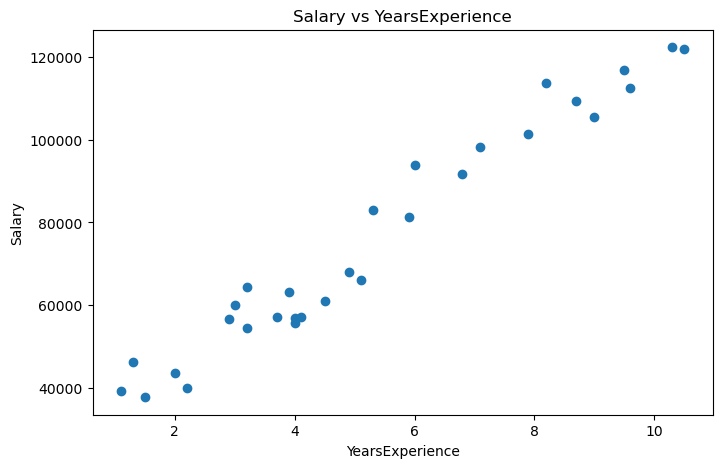

Train shape: (24, 1) Test shape: (6, 1)
Slope (m): 9423.815323030976
Intercept (c): 25321.583011776813


array([115790.21011287,  71498.27809463, 102596.86866063,  75267.80422384,
        55477.79204548,  60189.69970699])

Predicted salary for 6 years experience: 81864.47494996266
Mean Squared Error: 49830096.85590839


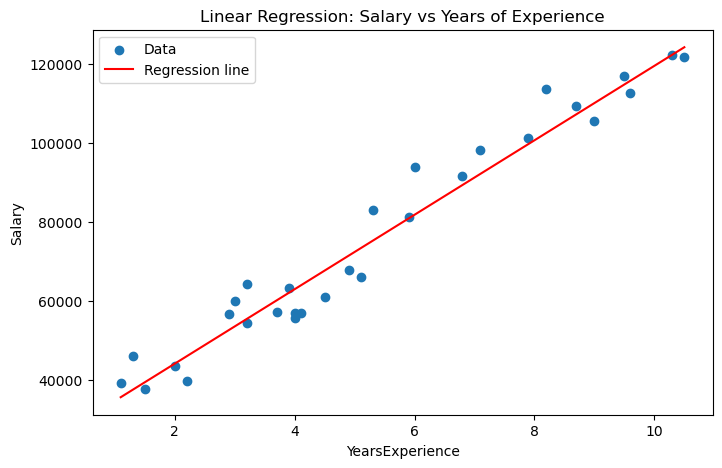

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load data
data = pd.read_csv('Salary_Data.csv')
# Show first rows
display(data.head())

# Basic dataset information
print('Shape:', data.shape)
print('Columns:', data.columns.tolist())
display(data.describe())

# Scatter plot: YearsExperience vs Salary
plt.figure(figsize=(8,5))
plt.scatter(data['YearsExperience'], data['Salary'])
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.title('Salary vs YearsExperience')
plt.show()

# Prepare features (X) and target (y)
X = data[['YearsExperience']].values
y = data['Salary'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)
print('Slope (m):', model.coef_[0])
print('Intercept (c):', model.intercept_)

# Predictions on the test set
y_pred = model.predict(X_test)
display(y_pred)

# Predict for a new sample (6 years experience)
new_experience = np.array([[6]])
predicted_salary = model.predict(new_experience)
print('Predicted salary for 6 years experience:', predicted_salary[0])

# Evaluate with Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print('Mean Squared Error:', mse)

# Plot regression line across the data
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
y_line = model.predict(X_line)

plt.figure(figsize=(8,5))
plt.scatter(X, y, label='Data')
plt.plot(X_line, y_line, color='red', label='Regression line')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.title('Linear Regression: Salary vs Years of Experience')
plt.legend()
plt.show()

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')
Predicted Sales for TV = 150: 15.329550017961328
Mean Absolute Error: 1.9502948931650088
R² Score: 0.802561303423698


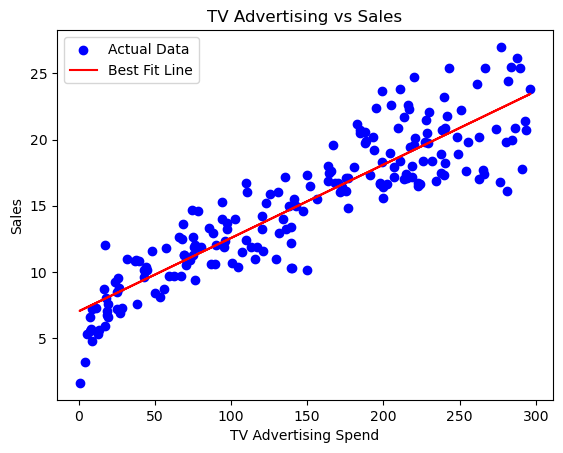

In [2]:
import pandas as pd

# Load dataset
data = pd.read_csv("advertising.csv")

print(data.head())

print(data.columns)
X = data[['TV']]     # Input feature
y = data['Sales']    # Target variable
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


tv_value = pd.DataFrame({'TV': [150]})
prediction_150 = model.predict(tv_value)

print("Predicted Sales for TV = 150:", prediction_150[0])


# Measure Accuracy

from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)
#Visualization
 
import matplotlib.pyplot as plt

plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, model.predict(X), color='red', label='Best Fit Line')

plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")
plt.title("TV Advertising vs Sales")
plt.legend()
plt.show()

In [ ]:
# 1) Data Preprocessing - Code
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from google.colab import drive
sns.set(style='whitegrid')
 

 
# Mount your Drive
drive.mount('/content/drive')
 
# Once mounted, navigate to the folder
# Example path (adjust based on your structure)
path = '/content/drive/My Drive/Data Sets/50_Startups.csv'
 
dataset = pd.read_csv(path)
print('Dataset shape:', dataset.shape)
display(dataset.head())
 
# Separate features and target
X = dataset.iloc[:, :-1].values  # all columns except last (Profit)
y = dataset.iloc[:, -1].values   # last column (Profit)
 
print('\nFeature preview (first 5 rows):')
print(X[:5])
 
# Encode categorical 'State' column (index 3)
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')
X_encoded = ct.fit_transform(X)
 
# Convert to numpy array and inspect
X = np.array(X_encoded)
print('\nAfter OneHotEncoding, feature shape:', X.shape)
print('\nFirst 5 rows after encoding:')
print(X[:5])
 
 
# 2) Fit Model - Code
# Splitting into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
 
print('Training samples:', X_train.shape[0])
print('Test samples:', X_test.shape[0])
 
# Train the Multiple Linear Regression model
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)
 
print('Intercept:', regressor.intercept_)
print('Number of coefficients:', len(regressor.coef_))
 
 
# 3) Predict - Code
# Predicting Test set results
y_pred = regressor.predict(X_test)
 
# Compare Actual vs Predicted
comparison = pd.DataFrame({
    'Actual Profit': y_test,
    'Predicted Profit': np.round(y_pred,2)
})
display(comparison.reset_index(drop=True))
 
 
# 4) Visualization - Code
# Visualization: Actual vs Predicted profits (scatter)
plt.figure(figsize=(10,6))
plt.scatter(range(len(y_test)), y_test, color='red', label='Actual Profit', alpha=0.7, s=60)
plt.scatter(range(len(y_pred)), y_pred, color='blue', label='Predicted Profit', alpha=0.7, marker='x', s=60)
plt.title('Actual vs Predicted Profit (Test Set)')
plt.xlabel('Test Sample Index')
plt.ylabel('Profit')
plt.legend()
plt.show()
 
# Residuals plot
residuals = y_test - y_pred
plt.figure(figsize=(10,5))
sns.histplot(residuals, kde=True)
plt.title('Residuals Distribution (Actual - Predicted)')
plt.xlabel('Residual')
plt.show()
 
# Residuals vs Predicted (to check heteroscedasticity)
plt.figure(figsize=(10,5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residuals vs Predicted')
plt.xlabel('Predicted Profit')
plt.ylabel('Residual (Actual - Predicted)')
plt.show()
 
 
# Evaluation metrics & sample prediction
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
 
mse = mean_squared_error(y_test, y_pred)
 
r2 = r2_score(y_test, y_pred)
 
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'R^2 Score: {r2:.4f}')
 
# Sample prediction: build raw sample and encode using ct (same transformer used earlier)
raw_sample = np.array([[160000, 130000, 300000, 'California']])
encoded_sample = ct.transform(raw_sample)
encoded_sample = np.array(encoded_sample, dtype=float)
pred_sample = regressor.predict(encoded_sample)
print('\nSample startup predicted profit:', float(pred_sample[0]))
 
 

NameError: name 'drive' is not defined

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')
Predicted Sales: 15.039523680317233
Mean Absolute Error: 1.274826210954934
Mean Squared Error: 2.907756910271091
R² Score: 0.9059011844150826
  Advertising Medium  Coefficient
0                 TV     0.054509
1              Radio     0.100945
2          Newspaper     0.004337


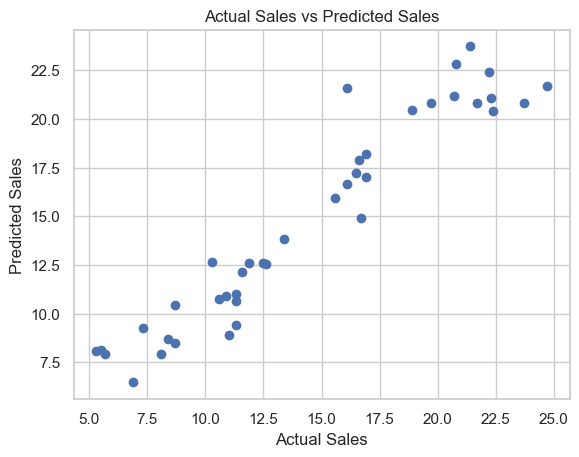

In [7]:
import pandas as pd

# Load dataset
data = pd.read_csv("advertising.csv")

# View first rows
print(data.head())

# Check columns
print(data.columns)
X = data[['TV', 'Radio', 'Newspaper']]  # Input features
y = data['Sales']                       
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

new_budget = pd.DataFrame({
    'TV': [150],
    'Radio': [20],
    'Newspaper': [30]
})

predicted_sales = model.predict(new_budget)
print("Predicted Sales:", predicted_sales[0])
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R² Score:", r2)
coefficients = pd.DataFrame({
    'Advertising Medium': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual Sales vs Predicted Sales")
plt.show()


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("Advertising.csv")

print(data.head())
print(data.columns)

# Input features (Multiple)
X = data[['TV', 'Radio', 'Newspaper']]
y = data['Sales']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Predict for new values
new_data = pd.DataFrame({
    'TV': [150],
    'Radio': [25],
    'Newspaper': [20]
})

prediction = model.predict(new_data)
print("Predicted Sales:", prediction[0])

# Model parameters
print("\nIntercept:", model.intercept_)
print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")

# Evaluation
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean Absolute Error:", mae)
print("R² Score:", r2)

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')
Predicted Sales: 15.500884024061671

Intercept: 4.714126402214134
Coefficients:
TV: 0.05450927083721976
Radio: 0.10094536239295573
Newspaper: 0.004336646822034021

Mean Absolute Error: 1.274826210954934
R² Score: 0.9059011844150826


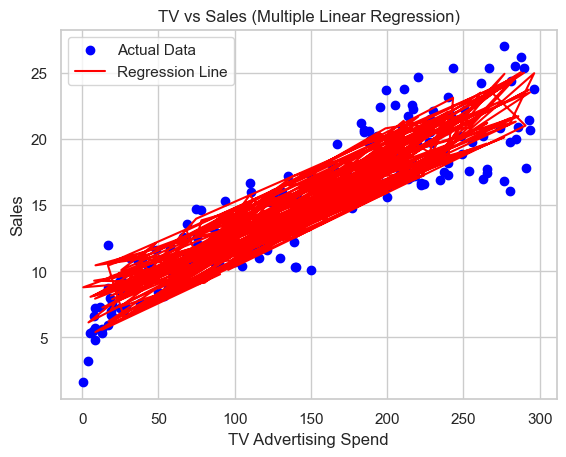

In [9]:
plt.scatter(data['TV'], y, color='blue', label='Actual Data')
plt.plot(data['TV'], model.predict(X), color='red', label='Regression Line')

plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")
plt.title("TV vs Sales (Multiple Linear Regression)")
plt.legend()
plt.show()